# Medicare Geographic Variation Analysis (2019–2023)

## Objective
Analyze drivers of variation in standardized Medicare spending per capita across U.S. counties from 2019–2023.

## Data Source
2014–2023 Medicare Fee-for-Service Geographic Variation Public Use File (CMS)

## Focus
- County-level data
- Age level: All
- Years: 2019–2023

## 1. Load Data

In [1]:
import pandas as pd

file_path = "../data/2014-2023 Medicare Fee-for-Service Geographic Variation Public Use File.csv"

df = pd.read_csv(file_path)

df.shape

/var/folders/zp/k8mn69sd37xcclqbkt404f5m0000gn/T/ipykernel_15838/1882590400.py:5: DtypeWarning: Columns (0: TOT_PBPMT_RDCTN_AMT, 1: TOT_PBPMT_RDCTN_PCC) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


(33639, 247)

In [2]:
df.head()

,YEAR,BENE_GEO_LVL,BENE_GEO_DESC,BENE_GEO_CD,BENE_AGE_LVL,BENES_TOTAL_CNT,BENES_WTH_PTAPTB_CNT,BENES_FFS_CNT,BENES_MA_CNT,MA_PRTCPTN_RATE,...,PQI11_BCTRL_PNA_AGE_LT_65,PQI11_BCTRL_PNA_AGE_65_74,PQI11_BCTRL_PNA_AGE_GE_75,PQI12_UTI_AGE_LT_65,PQI12_UTI_AGE_65_74,PQI12_UTI_AGE_GE_75,PQI15_ASTHMA_AGE_LT_40,PQI16_LWRXTRMTY_AMPUTN_AGE_LT_65,PQI16_LWRXTRMTY_AMPUTN_AGE_65_74,PQI16_LWRXTRMTY_AMPUTN_AGE_GE_75
0,2014,National,National,NaN,All,56767775,49302821,33462969,15839852,0.3213,...,686,499,1373,361,269,1120,286,147,50,47
1,2014,National,National,NaN,<65,9286837,7824336,5867170,1957166,0.2501,...,686,NaN,NaN,361,NaN,NaN,286,147,NaN,NaN
2,2014,National,National,NaN,>=65,47480938,41478485,27595799,13882686,0.3347,...,NaN,499,1373,NaN,269,1120,NaN,NaN,50,47
3,2014,State,AK,2.0,All,84573,71860,71383,477,0.0066,...,622,366,1271,181,152,703,*,130,*,72
4,2014,State,AK,2.0,<65,13294,11641,11578,63,0.0054,...,622,NaN,NaN,181,NaN,NaN,*,130,NaN,NaN


In [3]:
len(df.columns)

247

In [4]:
df.columns[:20]

Index(['YEAR', 'BENE_GEO_LVL', 'BENE_GEO_DESC', 'BENE_GEO_CD', 'BENE_AGE_LVL',
       'BENES_TOTAL_CNT', 'BENES_WTH_PTAPTB_CNT', 'BENES_FFS_CNT',
       'BENES_MA_CNT', 'MA_PRTCPTN_RATE', 'BENE_AVG_AGE', 'BENE_FEML_PCT',
       'BENE_MALE_PCT', 'BENE_RACE_WHT_PCT', 'BENE_RACE_BLACK_PCT',
       'BENE_RACE_HSPNC_PCT', 'BENE_RACE_OTHR_PCT', 'BENE_DUAL_PCT',
       'BENE_AVG_RISK_SCRE', 'TOT_MDCR_PYMT_AMT'],
      dtype='str')

In [5]:
df['BENE_GEO_LVL'].value_counts()

BENE_GEO_LVL
County      31959
State        1650
National       30
Name: count, dtype: int64

## 2. Filter to County-Level Observations

In [6]:
df_county = df[df['BENE_GEO_LVL'] == 'County'].copy()

df_county.shape

(31959, 247)

## 3. Restrict to 2019–2023

In [7]:
df_county['YEAR'].unique()

array([2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

In [8]:
df_recent = df_county[df_county['YEAR'] >= 2019].copy()

df_recent.shape

(15983, 247)

In [9]:
df_recent['BENE_AGE_LVL'].value_counts()

BENE_AGE_LVL
All    15983
Name: count, dtype: int64

In [10]:
df_final = df_recent[df_recent['BENE_AGE_LVL'] == 'All'].copy()

df_final.shape

(15983, 247)

In [11]:
df_recent['BENE_AGE_LVL'].value_counts()

BENE_AGE_LVL
All    15983
Name: count, dtype: int64

## 4. Select Key Analytical Variables

In [12]:
[c for c in df_final.columns if 'PYMT' in c or 'AMT' in c]

['TOT_MDCR_PYMT_AMT',
 'TOT_MDCR_STDZD_PYMT_AMT',
 'TOT_MDCR_PYMT_PC',
 'TOT_MDCR_STDZD_PYMT_PC',
 'IP_MDCR_PYMT_AMT',
 'IP_MDCR_PYMT_PCT',
 'IP_MDCR_PYMT_PC',
 'IP_MDCR_PYMT_PER_USER',
 'IP_MDCR_STDZD_PYMT_AMT',
 'IP_MDCR_STDZD_PYMT_PCT',
 'IP_MDCR_STDZD_PYMT_PC',
 'IP_MDCR_STDZD_PYMT_PER_USER',
 'OP_MDCR_PYMT_AMT',
 'OP_MDCR_PYMT_PCT',
 'OP_MDCR_PYMT_PC',
 'OP_MDCR_PYMT_PER_USER',
 'OP_MDCR_STDZD_PYMT_AMT',
 'OP_MDCR_STDZD_PYMT_PCT',
 'OP_MDCR_STDZD_PYMT_PC',
 'OP_MDCR_STDZD_PYMT_PER_USER',
 'ASC_MDCR_PYMT_AMT',
 'ASC_MDCR_PYMT_PCT',
 'ASC_MDCR_PYMT_PC',
 'ASC_MDCR_PYMT_PER_USER',
 'ASC_MDCR_STDZD_PYMT_AMT',
 'ASC_MDCR_STDZD_PYMT_PCT',
 'ASC_MDCR_STDZD_PYMT_PC',
 'ASC_MDCR_STDZD_PYMT_PER_USER',
 'SNF_MDCR_PYMT_AMT',
 'SNF_MDCR_PYMT_PCT',
 'SNF_MDCR_PYMT_PC',
 'SNF_MDCR_PYMT_PER_USER',
 'SNF_MDCR_STDZD_PYMT_AMT',
 'SNF_MDCR_STDZD_PYMT_PCT',
 'SNF_MDCR_STDZD_PYMT_PC',
 'SNF_MDCR_STDZD_PYMT_PER_USER',
 'IRF_MDCR_PYMT_AMT',
 'IRF_MDCR_PYMT_PCT',
 'IRF_MDCR_PYMT_PC',
 'IRF_MDCR_PYMT_PER_U

In [13]:
[c for c in df_final.columns if 'CNT' in c]

['BENES_TOTAL_CNT',
 'BENES_WTH_PTAPTB_CNT',
 'BENES_FFS_CNT',
 'BENES_MA_CNT',
 'BENES_IP_CVRD_STAY_CNT',
 'ACUTE_HOSP_READMSN_CNT',
 'BENES_ER_VISITS_CNT',
 'BENES_OP_CNT',
 'BENES_ASC_CNT',
 'BENES_SNF_CNT',
 'BENES_IRF_CNT',
 'BENES_LTCH_CNT',
 'BENES_HH_CNT',
 'BENES_HOSPC_CNT',
 'BENES_EM_CNT',
 'BENES_PRCDRS_CNT',
 'BENES_TESTS_CNT',
 'BENES_IMGNG_CNT',
 'BENES_DME_CNT',
 'BENES_OP_DLYS_CNT',
 'BENES_FQHC_RHC_CNT',
 'BENES_AMBLNC_CNT',
 'BENES_TRTMNTS_CNT']

In [14]:
key_cols = [
    'YEAR',
    'BENE_GEO_DESC',
    'TOT_MDCR_STDZD_PYMT_PC',
    'BENE_AVG_RISK_SCRE',
    'BENE_AVG_AGE',
    'BENE_DUAL_PCT',
    'IP_CVRD_STAYS_PER_1000_BENES',
    'ER_VISITS_PER_1000_BENES',
    'ACUTE_HOSP_READMSN_PCT'
]

df_analysis = df_final[key_cols]

df_analysis.describe()

,YEAR
count,15983.000000
mean,2021.000563
std,1.414236
min,2019.000000
25%,2020.000000
50%,2021.000000
75%,2022.000000
max,2023.000000


## 5. Convert Data Types

In [15]:
for col in df_analysis.columns:
    if col != 'BENE_GEO_DESC':  # keep county name as string
        df_analysis[col] = pd.to_numeric(df_analysis[col], errors='coerce')

## 6. Distribution of Spending

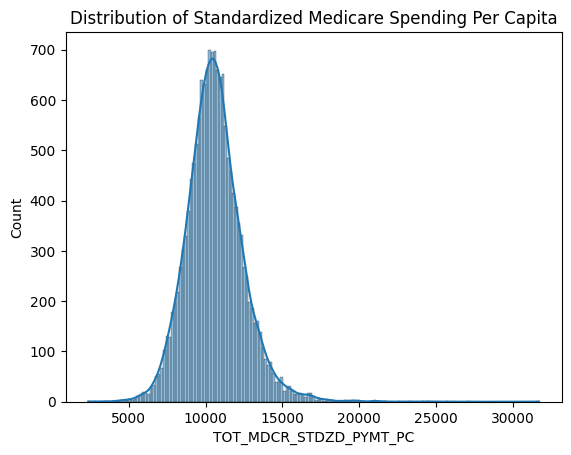

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_analysis['TOT_MDCR_STDZD_PYMT_PC'], kde=True)
plt.title("Distribution of Standardized Medicare Spending Per Capita")
plt.show()

## 7. Correlation Analysis

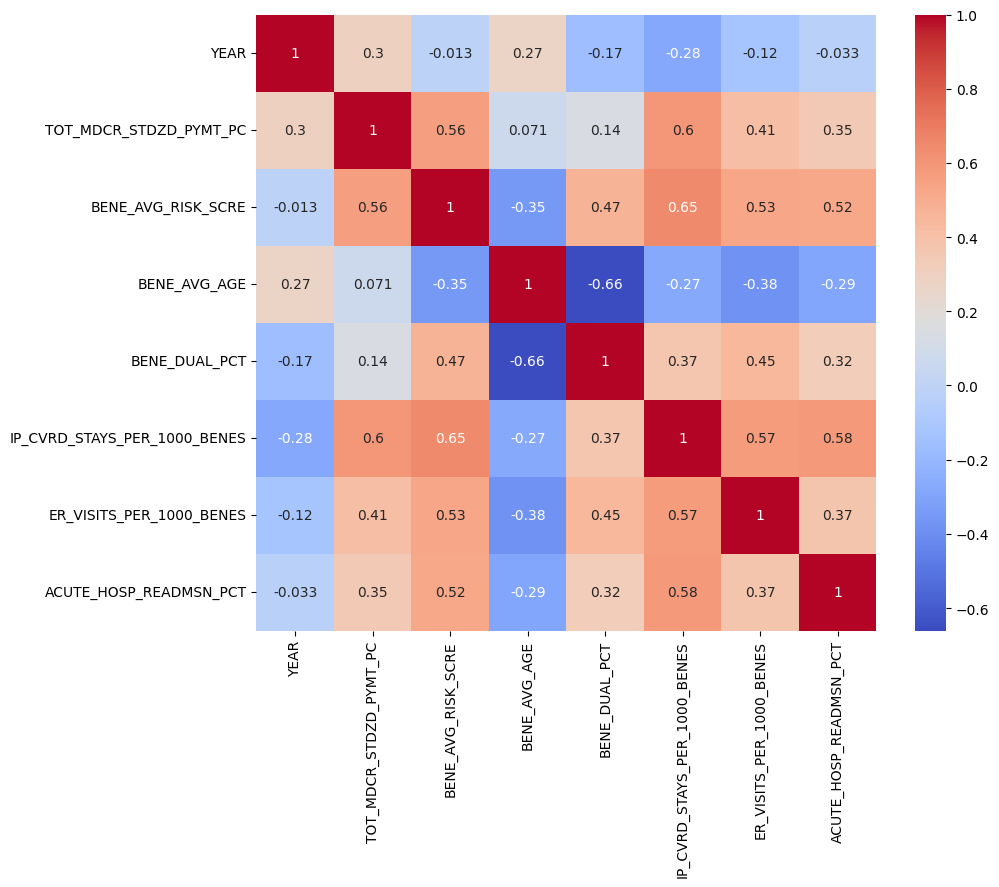

In [17]:
corr = df_analysis.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()